In [ ]:
import os
import numpy as np
import random
from PIL import Image,ImageEnhance

# keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Flatten, Dropout
from tensorflow.keras.preprocessing.image import load_img
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.applications import VGG16
from sklearn.utils import shuffle

In [ ]:
train_dir = '/content/drive/MyDrive/MRI Images/Training'
test_dir = '/content/drive/MyDrive/MRI Images/Testing'

In [ ]:
#load train data
train_paths = []
train_labels = []

for label in os.listdir(train_dir):
  for image in os.listdir(os.path.join(train_dir,label)):
    train_paths.append(os.path.join(train_dir,label,image))
    train_labels.append(label)

# shuffle train data
train_paths,train_labels = shuffle(train_paths,train_labels)

In [ ]:
#load test data
test_paths = []
test_labels = []

for label in os.listdir(test_dir):
  for image in os.listdir(os.path.join(test_dir,label)):
    test_paths.append(os.path.join(test_dir,label,image))
    test_labels.append(label)

# shuffle testdata
test_paths,test_labels = shuffle(test_paths,test_labels)

##**DATA VISUALIZATION**




In [ ]:
import random
import matplotlib.pyplot as plt

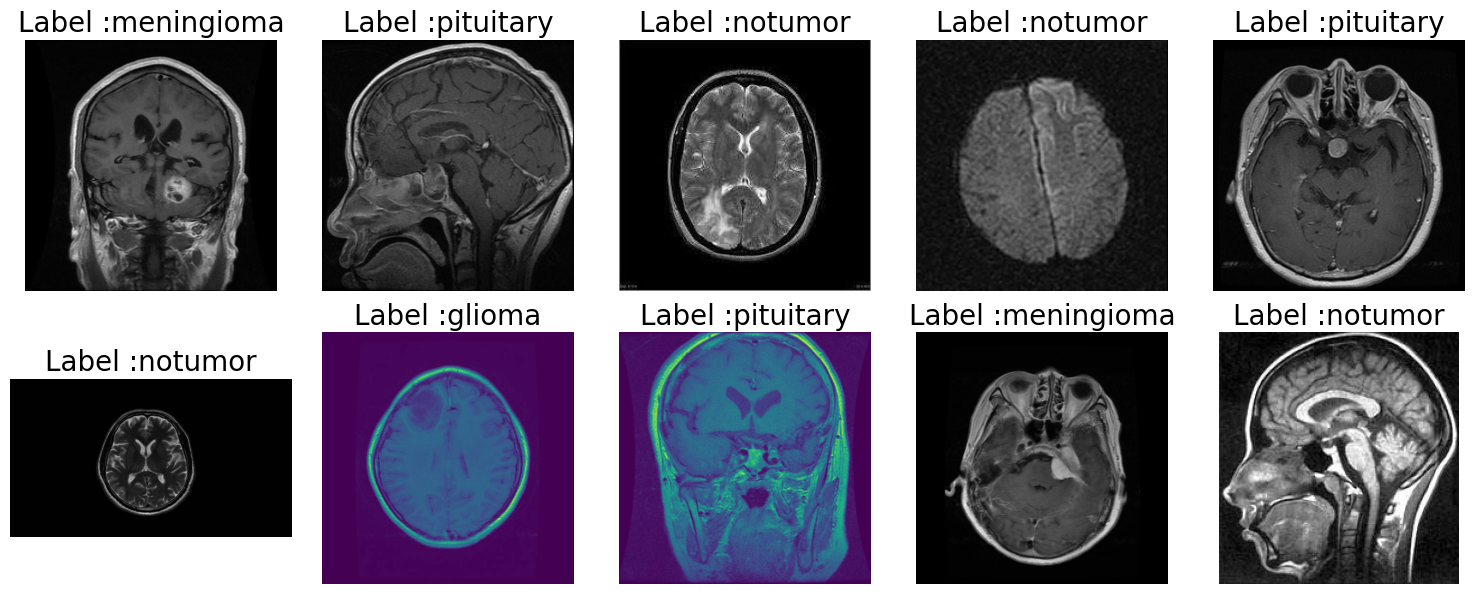

In [ ]:
#selecting random images
random_indices = random.sample(range(len(train_paths)),10)
random_indices

fig,axes = plt.subplots(2,5,figsize=(15,6))
axes = axes.ravel()

for i,ind in enumerate(random_indices):
  img_path = train_paths[ind]
  img = Image.open(img_path)
  img.resize((128,128))

  #display image
  axes[i].imshow(img)
  axes[i].axis("off")
  axes[i].set_title(f"Label :{train_labels[ind]}",fontsize=20)

plt.tight_layout()
plt.show()

## Image Preprocessing

In [ ]:
# Image Augmentation Function

def augment_img(image):
  image = Image.fromarray(np.uint8(image))
  image = ImageEnhance.Brightness(image).enhance(random.uniform(0.8,1.2))
  image = ImageEnhance.Contrast(image).enhance(random.uniform(0.8,1.2))
  image = np.array(image)/255.0
  return image

In [ ]:
def augment_img(image):
    image = Image.fromarray(np.uint8(image))

    if random.random() < 0.3:
        image = ImageEnhance.Brightness(image).enhance(random.uniform(0.9, 1.1))

    if random.random() < 0.3:
        image = ImageEnhance.Contrast(image).enhance(random.uniform(0.9, 1.1))

    if random.random() < 0.3:
        image = image.rotate(random.uniform(-10, 10))

    image = np.array(image) / 255.0
    return image

In [ ]:
#load images and apply augmentation
def open_images(paths):
  images = []
  for path in paths:
    img = load_img(path,target_size = (img_size,img_size))
    img = augment_img(img)
    images.append(img)
  return np.array(images)

In [ ]:
label_to_index = {label: i for i, label in enumerate(sorted(os.listdir(train_dir)))}

In [ ]:
#Encoding labels
def encode_labels(batch_labels):
   return np.array([label_to_index[label] for label in batch_labels])

In [ ]:
#Data generator
def datagen(paths,labels,batch_size=12, epoch=1):
  for _ in range(epoch):
    for i in range(0,len(paths),batch_size):
      batch_paths = paths[i:i+batch_size]
      batch_images = open_images(batch_paths)

      batch_labels = labels[i:i+batch_size]
      batch_labels = encode_labels(batch_labels)

      #print("batch_images shape:", getattr(batch_images, "shape", type(batch_images)))
      #print("batch_labels shape:", getattr(batch_labels, "shape", type(batch_labels)))

      yield batch_images,batch_labels

In [ ]:
def datagen(paths, labels, batch_size=12, epoch=1):
  for _ in range(epoch):
    indices = np.arange(len(paths))
    np.random.shuffle(indices)  # Shuffle data at start of each epoch

    for i in range(0, len(indices), batch_size):
      batch_indices = indices[i:i+batch_size]
      batch_paths = [paths[j] for j in batch_indices]
      batch_labels = [labels[j] for j in batch_indices]

      batch_images = open_images(batch_paths)
      batch_labels = encode_labels(batch_labels)

      yield batch_images, batch_labels

##**Model Building**

In [ ]:
img_size = 128

In [ ]:

base_model = VGG16(input_shape=(img_size,img_size,3),include_top=False, weights='imagenet')

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
#freezing all layers
for layer in base_model.layers:
  layer.trainable = False

#except last 4 layers

for layer in base_model.layers[-3:]:
    layer.trainable = True

In [ ]:
# final model
model = Sequential()
model.add(Input(shape=(img_size,img_size,3)))
model.add(base_model)
model.add(Flatten())
model.add(Dropout(0.3))

model.add(Dense(128,activation='relu'))
model.add(Dropout(0.2))

model.add(Dense(len(os.listdir(train_dir)),activation='softmax'))

In [ ]:
from keras.layers import BatchNormalization

In [ ]:
model = Sequential()
model.add(Input(shape=(img_size, img_size, 3)))
model.add(base_model)
model.add(Flatten())
model.add(BatchNormalization())
model.add(Dense(512, activation='relu'))
model.add(Dropout(0.4))
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(len(os.listdir(train_dir)), activation='softmax'))

In [ ]:
#compile model
model.compile(optimizer =Adam(learning_rate=0.0001),loss='sparse_categorical_crossentropy',metrics=['sparse_categorical_accuracy'])

In [ ]:
#Parameters
batch_size = 20
steps = int(len(train_paths)/batch_size)
epochs = 5

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

early = EarlyStopping(patience=5, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(patience=3, factor=0.5, verbose=1)


In [ ]:
#Training model
model.fit(
    datagen(train_paths,train_labels,batch_size=batch_size,epoch = epochs),
    steps_per_epoch = steps, callbacks=[early, reduce_lr]
)

285/285 ━━━━━━━━━━━━━━━━━━━━ 1102s 4s/step - loss: 0.6897 - sparse_categorical_accuracy: 0.7437 - learning_rate: 1.0000e-04


/usr/local/lib/python3.11/dist-packages/keras/src/callbacks/early_stopping.py:153: UserWarning: Early stopping conditioned on metric `val_loss` which is not available. Available metrics are: loss,sparse_categorical_accuracy
  current = self.get_monitor_value(logs)
/usr/local/lib/python3.11/dist-packages/keras/src/callbacks/callback_list.py:145: UserWarning: Learning rate reduction is conditioned on metric `val_loss` which is not available. Available metrics are: loss,sparse_categorical_accuracy,learning_rate.
  callback.on_epoch_end(epoch, logs)


In [ ]:
for layer in base_model.layers[:-10]:
    layer.trainable = False
for layer in base_model.layers[-10:]:
    layer.trainable = True

# Recompile with smaller learning rate
model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Train for a few more epochs
 model.fit(
    datagen(train_paths, train_labels, batch_size=batch_size,epoch = epochs),
    steps_per_epoch=steps,
    epochs=5,
    callbacks=[early, reduce_lr]
)

Epoch 1/5
285/285 ━━━━━━━━━━━━━━━━━━━━ 38s 109ms/step - accuracy: 0.9777 - loss: 0.0742 - learning_rate: 1.0000e-05
Epoch 2/5


/usr/local/lib/python3.11/dist-packages/keras/src/callbacks/early_stopping.py:153: UserWarning: Early stopping conditioned on metric `val_loss` which is not available. Available metrics are: accuracy,loss
  current = self.get_monitor_value(logs)
/usr/local/lib/python3.11/dist-packages/keras/src/callbacks/callback_list.py:145: UserWarning: Learning rate reduction is conditioned on metric `val_loss` which is not available. Available metrics are: accuracy,loss,learning_rate.
  callback.on_epoch_end(epoch, logs)


KeyboardInterrupt: 

In [ ]:
from sklearn.model_selection import train_test_split

train_paths1, val_paths1, train_labels1, val_labels1 = train_test_split(
    train_paths, train_labels, test_size=0.15, stratify=train_labels, random_state=42
)

In [ ]:
val_X, val_y = next(datagen(val_paths1, val_labels1, batch_size=len(val_paths1), epoch=1))
val_preds = model.predict(val_X)
val_preds_labels = np.argmax(val_preds, axis=1)

from sklearn.metrics import accuracy_score
print("Validation Accuracy:", accuracy_score(val_y, val_preds_labels))

27/27 ━━━━━━━━━━━━━━━━━━━━ 12s 253ms/step
Validation Accuracy: 0.970828471411902


In [ ]:
train_paths[:15]

['/content/drive/MyDrive/MRI Images/Training/meningioma/Tr-me_0406.jpg',
 '/content/drive/MyDrive/MRI Images/Training/meningioma/Tr-me_0999.jpg',
 '/content/drive/MyDrive/MRI Images/Training/pituitary/Tr-pi_0666.jpg',
 '/content/drive/MyDrive/MRI Images/Training/notumor/Tr-no_0903.jpg',
 '/content/drive/MyDrive/MRI Images/Training/pituitary/Tr-pi_0877.jpg',
 '/content/drive/MyDrive/MRI Images/Training/meningioma/Tr-me_0253.jpg',
 '/content/drive/MyDrive/MRI Images/Training/meningioma/Tr-me_0219.jpg',
 '/content/drive/MyDrive/MRI Images/Training/meningioma/Tr-me_0765.jpg',
 '/content/drive/MyDrive/MRI Images/Training/notumor/Tr-no_0203.jpg',
 '/content/drive/MyDrive/MRI Images/Training/meningioma/Tr-me_0246.jpg',
 '/content/drive/MyDrive/MRI Images/Training/meningioma/Tr-me_1197.jpg',
 '/content/drive/MyDrive/MRI Images/Training/meningioma/Tr-me_0506.jpg',
 '/content/drive/MyDrive/MRI Images/Training/notumor/Tr-no_0122.jpg',
 '/content/drive/MyDrive/MRI Images/Training/glioma/Tr-gl_0560

In [ ]:
train_labels[:15]

['meningioma',
 'meningioma',
 'pituitary',
 'notumor',
 'pituitary',
 'meningioma',
 'meningioma',
 'meningioma',
 'notumor',
 'meningioma',
 'meningioma',
 'meningioma',
 'notumor',
 'glioma',
 'notumor']

In [ ]:
encode_labels(train_labels)[:15]

array([1, 1, 3, 2, 3, 1, 1, 1, 2, 1, 1, 1, 2, 0, 2])

In [ ]:
from collections import Counter
print(Counter(train_labels))

Counter({'notumor': 1595, 'pituitary': 1457, 'meningioma': 1339, 'glioma': 1321})


In [ ]:
'''X, y = next(datagen(train_paths, train_labels, batch_size=4, epoch=1))
preds = model.predict(X)
print("True labels:", y)
print("Predicted labels:", np.argmax(preds, axis=1))'''

'X, y = next(datagen(train_paths, train_labels, batch_size=4, epoch=1))\npreds = model.predict(X)\nprint("True labels:", y)\nprint("Predicted labels:", np.argmax(preds, axis=1))'